# 第7回課題: 適用ドメイン (Applicability Domain)

`boston.csv` の `MEDV` を目的変数として回帰モデルを作成し、Hold-Out 検証で得られたテストデータが適用ドメイン (AD) 内か外かを判定します。

このノートブックでは、標準化した説明変数空間における **Euclidean距離** を使い、学習データ同士の **5近傍平均距離の95パーセンタイル** をADしきい値とします。テストデータの5近傍平均距離がしきい値以下ならAD内、しきい値より大きければAD外と判定します。

## 発表用スライド参照: 全体の使い方

- 使用スライド: `../適用ドメイン_説明用_シンプル_2026-07-03.pptx`
- 進め方: コードセルを実行して結果を見せる → 下の「スライド参照」セルの番号へ移動して説明 → ノートブックの次セクションへ戻る。
- スライドは「概念を説明する場所」、ノートブックは「実際に何を計算しているかを見せる場所」として使う。

## 1. ライブラリの読み込み

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42


## 発表用スライド参照: スライド 1-6

- ここでスライド 1-4 に移り、AD の直感・内挿/外挿・なぜ AD が必要かを説明する。
- スライド 5-6 で、今回の課題と全体ワークフローを確認する。
- 説明後は、このノートブックの「2. データの読み込み」に戻る。

## 2. データの読み込み

`MEDV` を目的変数、それ以外の列を説明変数として扱います。

In [13]:
data_path = Path("boston.csv")
df = pd.read_csv(data_path, index_col=0)

display(df.head())
print(f"データ数: {df.shape[0]}")
print(f"列数: {df.shape[1]}")
print(f"欠損値数: {int(df.isna().sum().sum())}")

,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
sample_1,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
sample_2,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
sample_3,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
sample_4,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
sample_5,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


データ数: 506
列数: 14
欠損値数: 0


In [14]:
target_col = "MEDV"

X = df.drop(columns=target_col)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print(f"学習データ数: {len(X_train)}")
print(f"テストデータ数: {len(X_test)}")

学習データ数: 379
テストデータ数: 127


## 発表用スライド参照: スライド 5, 7-9

- このコードで `MEDV` を目的変数、残りを説明変数に分け、Hold-Out で train/test に分割していることを見せる。
- スライド 7 で Boston データの概要、スライド 8 で X と y の分け方、スライド 9 で Hold-Out 検証を説明する。
- 説明後は「3. 前処理と複数回帰モデルの比較」に戻る。

## 3. 前処理と複数回帰モデルの比較

距離計算にスケールの影響が出るため、説明変数は学習データで標準化します。複数の回帰モデルを同じHold-Out分割で学習し、`MAE`、`RMSE`、`R^2` で比較します。

以降のAD解析では、比較表で `RMSE` が最小だったモデルの予測値を使います。ランダムフォレストの結果でAD解析したい場合は、次のコードセルの `selected_model_name` を `"Random Forest"` に変更してください。


Hold-Out 検証のモデル比較


,model,MAE,RMSE,R2
0,Gradient Boosting,2.028,2.993,0.872
1,Random Forest,2.176,3.359,0.839
2,Hist Gradient Boosting,2.104,3.376,0.837
3,Extra Trees,2.006,3.447,0.830
4,Decision Tree,2.718,3.709,0.804
5,SVR (RBF),2.130,3.755,0.799
6,AdaBoost,2.690,4.002,0.771
7,kNN,2.557,4.488,0.712
8,Linear Regression,3.061,4.701,0.684
9,Ridge,3.059,4.703,0.684


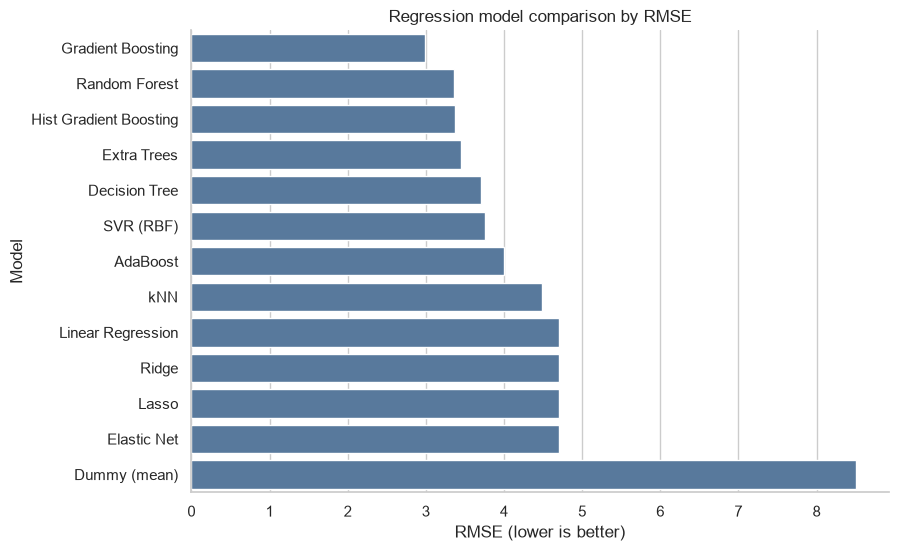

以降のAD解析に使うモデル: Gradient Boosting
Hold-Out 検証の予測性能（選択モデル）
MAE : 2.028
RMSE: 2.993
R^2 : 0.872


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000, random_state=RANDOM_STATE),
    "Elastic Net": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE),
    "kNN": KNeighborsRegressor(n_neighbors=5),
    "SVR (RBF)": SVR(kernel="rbf", C=10, epsilon=0.1),
    "Decision Tree": DecisionTreeRegressor(min_samples_leaf=2, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostRegressor(random_state=RANDOM_STATE),
}

model_predictions = {}
model_score_rows = []

for model_name, candidate_model in models.items():
    candidate_model.fit(X_train_scaled, y_train)
    candidate_pred = candidate_model.predict(X_test_scaled)
    model_predictions[model_name] = candidate_pred

    model_score_rows.append(
        {
            "model": model_name,
            "MAE": mean_absolute_error(y_test, candidate_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, candidate_pred)),
            "R2": r2_score(y_test, candidate_pred),
        }
    )

model_scores = (
    pd.DataFrame(model_score_rows)
    .sort_values("RMSE", ascending=True)
    .reset_index(drop=True)
)

print("Hold-Out 検証のモデル比較")
display(model_scores.round({"MAE": 3, "RMSE": 3, "R2": 3}))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=model_scores, x="RMSE", y="model", color="#4C78A8", ax=ax)
ax.set_title("Regression model comparison by RMSE")
ax.set_xlabel("RMSE (lower is better)")
ax.set_ylabel("Model")
plt.show()

selected_model_name = model_scores.loc[0, "model"]
model = models[selected_model_name]
y_pred = model_predictions[selected_model_name]

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"以降のAD解析に使うモデル: {selected_model_name}")
print("Hold-Out 検証の予測性能（選択モデル）")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2 : {r2:.3f}")


## 発表用スライド参照: スライド 10-13

- このコードで、標準化、複数モデルの学習、MAE/RMSE/R2 の比較、最良モデルの選択を行っている。
- スライド 10 で標準化の理由、スライド 11-12 で評価指標とモデル群、スライド 13 で比較結果を説明する。
- 説明後は「4. kNNによるADしきい値の計算」に戻る。

## 4. kNNによるADしきい値の計算

- 距離空間: 標準化した説明変数空間
- 距離指標: Euclidean距離
- k: 5
- しきい値: 学習データ同士の5近傍平均距離の95パーセンタイル

学習データ同士で近傍を取ると自分自身の距離0が含まれるため、`k + 1` 近傍を取得して自分自身を除外します。

In [16]:
k = 5
percentile = 95
metric = "euclidean"

nn = NearestNeighbors(n_neighbors=k + 1, metric=metric)
nn.fit(X_train_scaled)

# 訓練データ同士: 0列目は自分自身への距離0なので除外
train_distances, _ = nn.kneighbors(X_train_scaled)
train_knn_mean_distance = train_distances[:, 1:].mean(axis=1)
ad_threshold = np.percentile(train_knn_mean_distance, percentile)

# テストデータ: 自分自身は含まれないので先頭k列をそのまま使用
test_distances, _ = nn.kneighbors(X_test_scaled)
test_knn_mean_distance = test_distances[:, :k].mean(axis=1)

is_in_ad = test_knn_mean_distance <= ad_threshold

print(f"k = {k}")
print(f"距離指標 = {metric}")
print(f"ADしきい値 ({percentile}パーセンタイル) = {ad_threshold:.3f}")
print(f"AD内のテストデータ数: {int(is_in_ad.sum())}")
print(f"AD外のテストデータ数: {int((~is_in_ad).sum())}")

k = 5
距離指標 = euclidean
ADしきい値 (95パーセンタイル) = 2.435
AD内のテストデータ数: 123
AD外のテストデータ数: 4


## 発表用スライド参照: スライド 14-18

- このコードが AD 判定の中心。標準化済み説明変数空間で kNN 平均距離を計算している。
- スライド 14 で kNN 平均距離、スライド 15-16 で 95 パーセンタイルのしきい値、スライド 17 で test の AD 判定、スライド 18 で結果を説明する。
- `train_distances[:, 1:]` は、自分自身への距離 0 を除外するための処理として強調する。

## 5. テストデータごとのAD判定と誤差

In [17]:
results = pd.DataFrame(
    {
        "actual_MEDV": y_test,
        "predicted_MEDV": y_pred,
        "residual": y_test.to_numpy() - y_pred,
        "abs_error": np.abs(y_test.to_numpy() - y_pred),
        "knn_mean_distance": test_knn_mean_distance,
        "AD": np.where(is_in_ad, "inside", "outside"),
    },
    index=y_test.index,
)

display(results.sort_values("knn_mean_distance", ascending=False).head(10))

,actual_MEDV,predicted_MEDV,residual,abs_error,knn_mean_distance,AD
sample_419,8.8,6.575404,2.224596,2.224596,4.468247,outside
sample_415,7.0,7.372186,-0.372186,0.372186,3.923629,outside
sample_366,27.5,23.466945,4.033055,4.033055,2.766839,outside
sample_413,17.9,10.026804,7.873196,7.873196,2.757102,outside
sample_418,10.4,9.835359,0.564641,0.564641,2.092083,inside
sample_356,20.6,20.768106,-0.168106,0.168106,1.959757,inside
sample_399,5.0,5.656891,-0.656891,0.656891,1.857209,inside
sample_210,20.0,18.056128,1.943872,1.943872,1.799101,inside
sample_376,15.0,23.446399,-8.446399,8.446399,1.744267,inside
sample_205,50.0,45.283484,4.716516,4.716516,1.719813,inside


In [18]:
summary_by_ad = (
    results.groupby("AD")
    .agg(
        n=("actual_MEDV", "size"),
        MAE=("abs_error", "mean"),
        RMSE=("residual", lambda x: np.sqrt(np.mean(x**2))),
        mean_knn_distance=("knn_mean_distance", "mean"),
    )
    .sort_index()
)

display(summary_by_ad)

,n,MAE,RMSE,mean_knn_distance
AD,,,,
inside,123,1.975801,2.927428,1.087938
outside,4,3.625758,4.564540,3.478954


## 発表用スライド参照: スライド 18, 22

- ここでは test 各点の AD 判定と、AD 内外ごとの誤差集計を確認する。
- スライド 18 で AD 内 123 件・AD 外 4 件という全体結果を説明する。
- スライド 22 で AD 内外の MAE/RMSE を比較し、AD 外の平均誤差が大きいことを説明する。

## 6. 可視化1: 学習データ間の平均距離分布とADしきい値

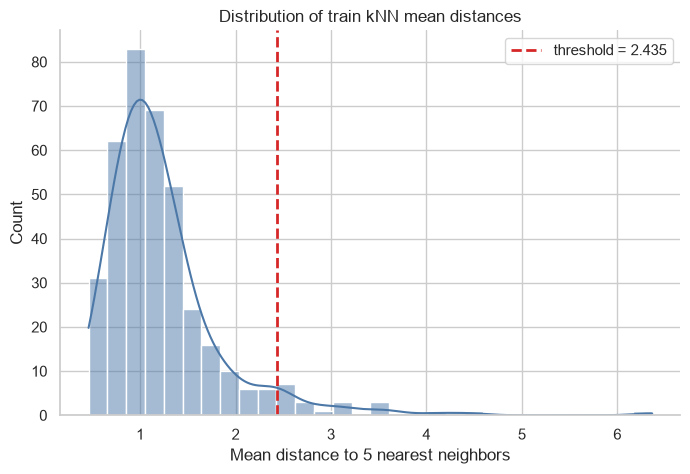

In [19]:
fig, ax = plt.subplots()

sns.histplot(train_knn_mean_distance, bins=30, kde=True, color="#4C78A8", ax=ax)
ax.axvline(ad_threshold, color="#D62728", linestyle="--", linewidth=2, label=f"threshold = {ad_threshold:.3f}")
ax.set_title("Distribution of train kNN mean distances")
ax.set_xlabel("Mean distance to 5 nearest neighbors")
ax.set_ylabel("Count")
ax.legend()

plt.show()

## 発表用スライド参照: スライド 19

- この図は、学習データ同士の 5 近傍平均距離の分布と AD しきい値を示している。
- スライド 19 に移り、赤破線より右側が「学習データの中でも疎な領域」であることを説明する。
- 説明後は「7. 可視化2」に戻る。

## 7. 可視化2: テストデータのk近傍距離と予測誤差

横軸がAD判定に使ったテストデータの5近傍平均距離、縦軸が絶対誤差です。赤い破線より右側はAD外です。

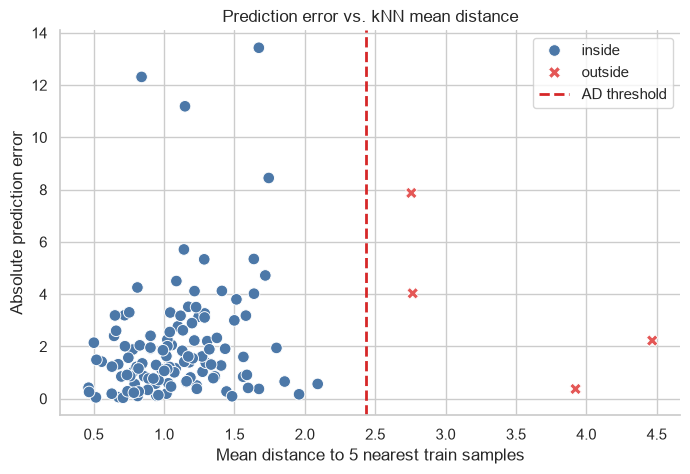

In [20]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=results,
    x="knn_mean_distance",
    y="abs_error",
    hue="AD",
    style="AD",
    palette={"inside": "#4C78A8", "outside": "#E45756"},
    s=70,
    ax=ax,
)
ax.axvline(ad_threshold, color="#D62728", linestyle="--", linewidth=2, label="AD threshold")
ax.set_title("Prediction error vs. kNN mean distance")
ax.set_xlabel("Mean distance to 5 nearest train samples")
ax.set_ylabel("Absolute prediction error")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title=None)

plt.show()

## 発表用スライド参照: スライド 20

- この図は、test の kNN 平均距離と予測誤差の関係を示している。
- スライド 20 に移り、赤破線より右側が AD 外であり、誤差が大きくなりやすい傾向を説明する。
- ただし「AD 外 = 必ず誤差が大きい」ではないことも補足する。

## 8. 予測値の信頼性の可視化

実測値と予測値の散布図をAD判定で色分けします。AD外の点は学習データから離れた外挿領域にあるため、予測値の信頼性が相対的に低いと考えられます。

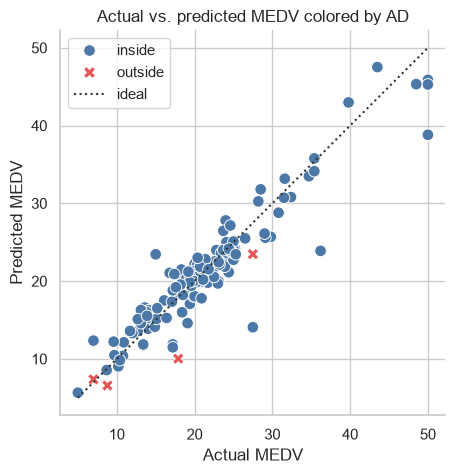

In [21]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=results,
    x="actual_MEDV",
    y="predicted_MEDV",
    hue="AD",
    style="AD",
    palette={"inside": "#4C78A8", "outside": "#E45756"},
    s=70,
    ax=ax,
)

min_value = min(results["actual_MEDV"].min(), results["predicted_MEDV"].min())
max_value = max(results["actual_MEDV"].max(), results["predicted_MEDV"].max())
ax.plot([min_value, max_value], [min_value, max_value], color="#333333", linestyle=":", label="ideal")
ax.set_title("Actual vs. predicted MEDV colored by AD")
ax.set_xlabel("Actual MEDV")
ax.set_ylabel("Predicted MEDV")
ax.set_aspect("equal", adjustable="box")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title=None)

plt.show()

## 発表用スライド参照: スライド 21, 24

- この図は、実測値と予測値の対応を AD 判定で色分けしている。
- スライド 21 で、対角線に近いほど予測が良いこと、AD 外点は信頼性を低めに見ることを説明する。
- スライド 24 の PCA 図は補助説明用。AD 計算そのものは PCA 後ではなく、元の 13 次元標準化空間で行っていると説明する。

## 9. AD外サンプルの確認

In [22]:
outside_ad = results[results["AD"] == "outside"].sort_values("knn_mean_distance", ascending=False)

if outside_ad.empty:
    print("このHold-Out分割ではAD外と判定されたテストデータはありませんでした。")
else:
    display(outside_ad)
    print(
        f"AD外サンプルのMAEは {outside_ad['abs_error'].mean():.3f} で、"
        f"全テストデータのMAE {mae:.3f} と比較して予測信頼性を確認できます。"
    )

,actual_MEDV,predicted_MEDV,residual,abs_error,knn_mean_distance,AD
sample_419,8.8,6.575404,2.224596,2.224596,4.468247,outside
sample_415,7.0,7.372186,-0.372186,0.372186,3.923629,outside
sample_366,27.5,23.466945,4.033055,4.033055,2.766839,outside
sample_413,17.9,10.026804,7.873196,7.873196,2.757102,outside


AD外サンプルのMAEは 3.626 で、全テストデータのMAE 2.028 と比較して予測信頼性を確認できます。


## 発表用スライド参照: スライド 23

- このコードで AD 外サンプルだけを取り出し、距離が大きい順に確認する。
- スライド 23 に移り、どのサンプルが学習データから離れているか、誤差と合わせて説明する。
- `sample_413` は AD 外かつ誤差が大きい例、`sample_415` は AD 外でも誤差が小さい例として使いやすい。

## 10. まとめ

- `MEDV` を目的変数としてHold-Out検証による回帰モデルを作成した。
- `DummyRegressor`、線形回帰、正則化線形モデル、kNN、SVR、決定木、ランダムフォレスト、Extra Trees、勾配ブースティング系モデルなどを同じデータ分割で比較した。
- 比較指標には `MAE`、`RMSE`、`R^2` を使用し、以降のAD解析では `RMSE` が最小だったモデルの予測値を用いた。
- 標準化した説明変数空間でEuclidean距離を計算し、学習データの5近傍平均距離の95パーセンタイルをADしきい値とした。
- テストデータの5近傍平均距離をしきい値と比較し、AD内・AD外を判定した。
- AD外の点は学習データから離れた外挿領域にあるため、予測値の信頼性が相対的に低いサンプルとして扱える。


## 発表用スライド参照: スライド 25-28

- スライド 25 でコード上の注意点を整理する。
- スライド 26 で AD の限界を説明する。
- スライド 27 で全体をまとめる。
- スライド 28 は発表者用の接続フレーズなので、必要に応じて表示する。